In [20]:
from optunaz.three_step_opt_build_merge import (
    optimize,
    buildconfig_best,
    build_best)

from optunaz.config import ModelMode, OptimizationDirection
from optunaz.config.optconfig import (
    OptimizationConfig,
    RandomForestClassifier,
    SVC,
    LogisticRegression,
    KNeighborsClassifier,
)
from optunaz.datareader import Dataset
from optunaz.descriptors import (ECFP,
                                 ECFP_counts,
                                 MACCS_keys,
                                 UnscaledPhyschemDescriptors,
                                 CompositeDescriptor,
                                 PhyschemDescriptors)
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import confusion_matrix as cm, classification_report, matthews_corrcoef
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import auc as AUC
from optunaz.utils.preprocessing.splitter import Stratified
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve, average_precision_score

QSARtunaModel(predictor=LogisticRegression(class_weight='balanced', n_jobs=-1, random_state=42,
                   solver='newton-cg'), descriptor=ECFP(name='ECFP', parameters=ECFP.Parameters(radius=3, nBits=2048, returnRdkit=False)), mode=<ModelMode.CLASSIFICATION: 'classification'>, transform=None, aux_transform=None, metadata={'name': '', 'buildconfig': {'data': {'training_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\sample_then_split\\train_set.csv', 'input_column': 'Structure', 'response_column': 'Class', 'response_type': 'classification', 'deduplication_strategy': {'name': 'KeepMedian'}, 'split_strategy': {'name': 'NoSplitting'}, 'test_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\sample_then_split\\test_set.csv', 'save_intermediate_files': False, 'log_transform': False, 'log_transform_base': None, 'log_transform_negative': None, 'log_transform_unit_conversion': None, 'probabilistic_threshold_representation': False, 'probabilistic_threshold_representation_threshold': None, 'probabil

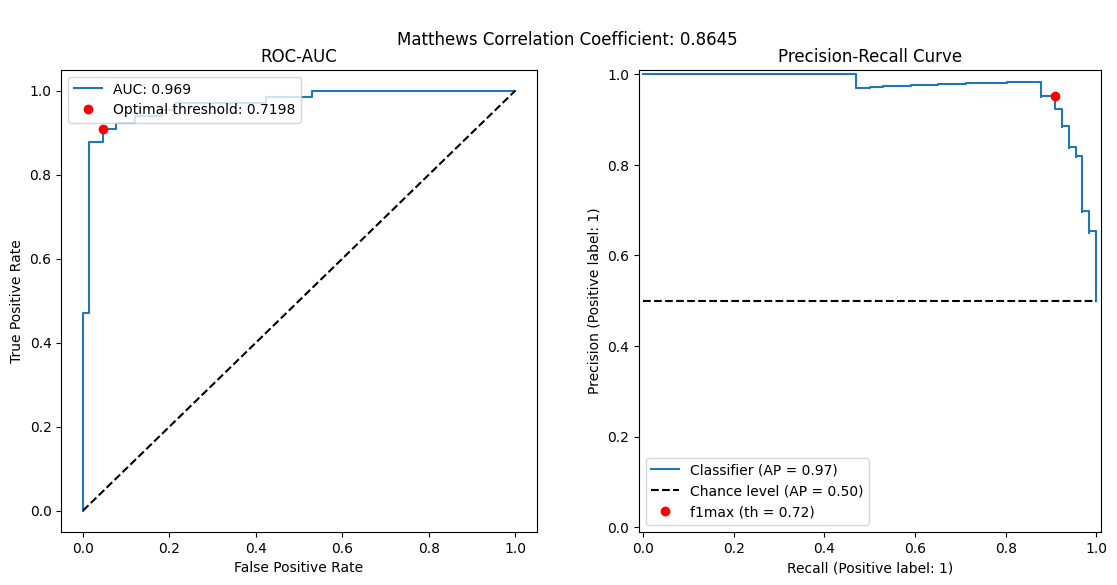

In [21]:
config = OptimizationConfig(
    data=Dataset(
            input_column='Structure',
            response_column='Class',
            training_dataset_file=r'M:\ML_scripts\MODEL DATA\sample_then_split\train_set.csv',
            test_dataset_file=r'M:\ML_scripts\MODEL DATA\sample_then_split\test_set.csv',
        ),
        descriptors=[
            ECFP.new(),
            ECFP_counts.new(),
            MACCS_keys.new(),
            PhyschemDescriptors.new(),
            UnscaledPhyschemDescriptors.new(),
            CompositeDescriptor.new(
                descriptors=[
                    ECFP_counts.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            ),
            CompositeDescriptor.new(
                descriptors=[
                    MACCS_keys.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            ),
            CompositeDescriptor.new(
                descriptors=[
                    ECFP.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            )
        ],
        algorithms=[
            RandomForestClassifier.new(),
            SVC.new(),
            LogisticRegression.new(),
            KNeighborsClassifier.new(),
        ],
        settings=OptimizationConfig.Settings(
            mode=ModelMode.CLASSIFICATION,
            cross_validation=10,
            cv_split_strategy=Stratified(),
            n_trials=200,
            n_startup_trials=50,
            direction=OptimizationDirection.MAXIMIZATION,
            random_seed=42,
            n_jobs=-1
        ),
    )

# optimize and build model

# study = optimize(config, study_name='sts_1')
# build_best(buildconfig_best(study), r"M:\ML_scripts\MODEL DATA\sample_then_split\model_1.pkl")

with open(r"M:\ML_scripts\MODEL DATA\sample_then_split\model_1.pkl", "rb") as m:
    model = pickle.load(m)

print(model)

# load test data

fig, axs = plt.subplots(1,2, figsize=(13.5, 6))         # create plots for curves

x = np.linspace(0,1)

test_data = pd.read_csv(config.data.test_dataset_file)  # load the test data
test_smiles = test_data[config.data.input_column]       # test structures
y_true = test_data[config.data.response_column]         # test ground truth labels

y_pred = model.predict_from_smiles(test_smiles)         # model predictions on test set structures

plt.subplot(121)

# Plotting the ROC curve

fpr, tpr, thresh = sklearn.metrics.roc_curve(y_true, y_pred) # false positive rate, true positive rate and thresholds
auc = np.trapz(tpr, fpr)                                     # AUC using trapezoidal rule
plt.plot(fpr, tpr)                                           # plot the ROC curve
axs[0].set_title('ROC-AUC')

# Optimal threshold using ROC curve

optimal_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
optimal_threshold = thresh[optimal_idx]

x_coord, y_coord = fpr[optimal_idx], tpr[optimal_idx]

plt.plot(x_coord, y_coord,'ro');

plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.legend([f'AUC: {auc:.4}', f"Optimal threshold: {optimal_threshold:.4}"], loc='upper left', fontsize=10);
plt.plot(x,x, 'k--', lw=1.5)

# Binary conversion of predictions

y_pred_bin = [1 if value >= optimal_threshold else 0 for value in y_pred]

mcc = matthews_corrcoef(y_pred_bin, y_true)
plt.suptitle(f"\nMatthews Correlation Coefficient: {mcc:.4}")   # matthews CC
# print(classification_report(y_true, y_pred_bin))              # classification report
# print(cm(y_true, y_pred_bin))                                 # confusion matrix

# Plotting the Precision-Recall curve

pos_label = 1 
name = "TM-1"

precision, recall, thresholds = precision_recall_curve(y_true, y_pred, pos_label=pos_label)     # precision, recall and thresholds
f1_scores = 2 * recall * precision / (recall + precision)                                       # https://stats.stackexchange.com/questions/596807/how-to-get-the-threshold-from-precisionrecalldisplay
best_th_ix = np.nanargmax(f1_scores)
best_thresh = thresholds[best_th_ix]

average_precision = average_precision_score(y_true, y_pred, pos_label=pos_label)
display = PrecisionRecallDisplay.from_predictions(y_true=y_true, y_pred=y_pred, pos_label=pos_label, plot_chance_level=True, ax=axs[1])

axs[1].plot(name=name)
axs[1].set_title("Precision-Recall Curve")
axs[1].plot(recall[best_th_ix], precision[best_th_ix], "ro", label=f"f1max (th = {best_thresh:.2f})")
axs[1].legend();

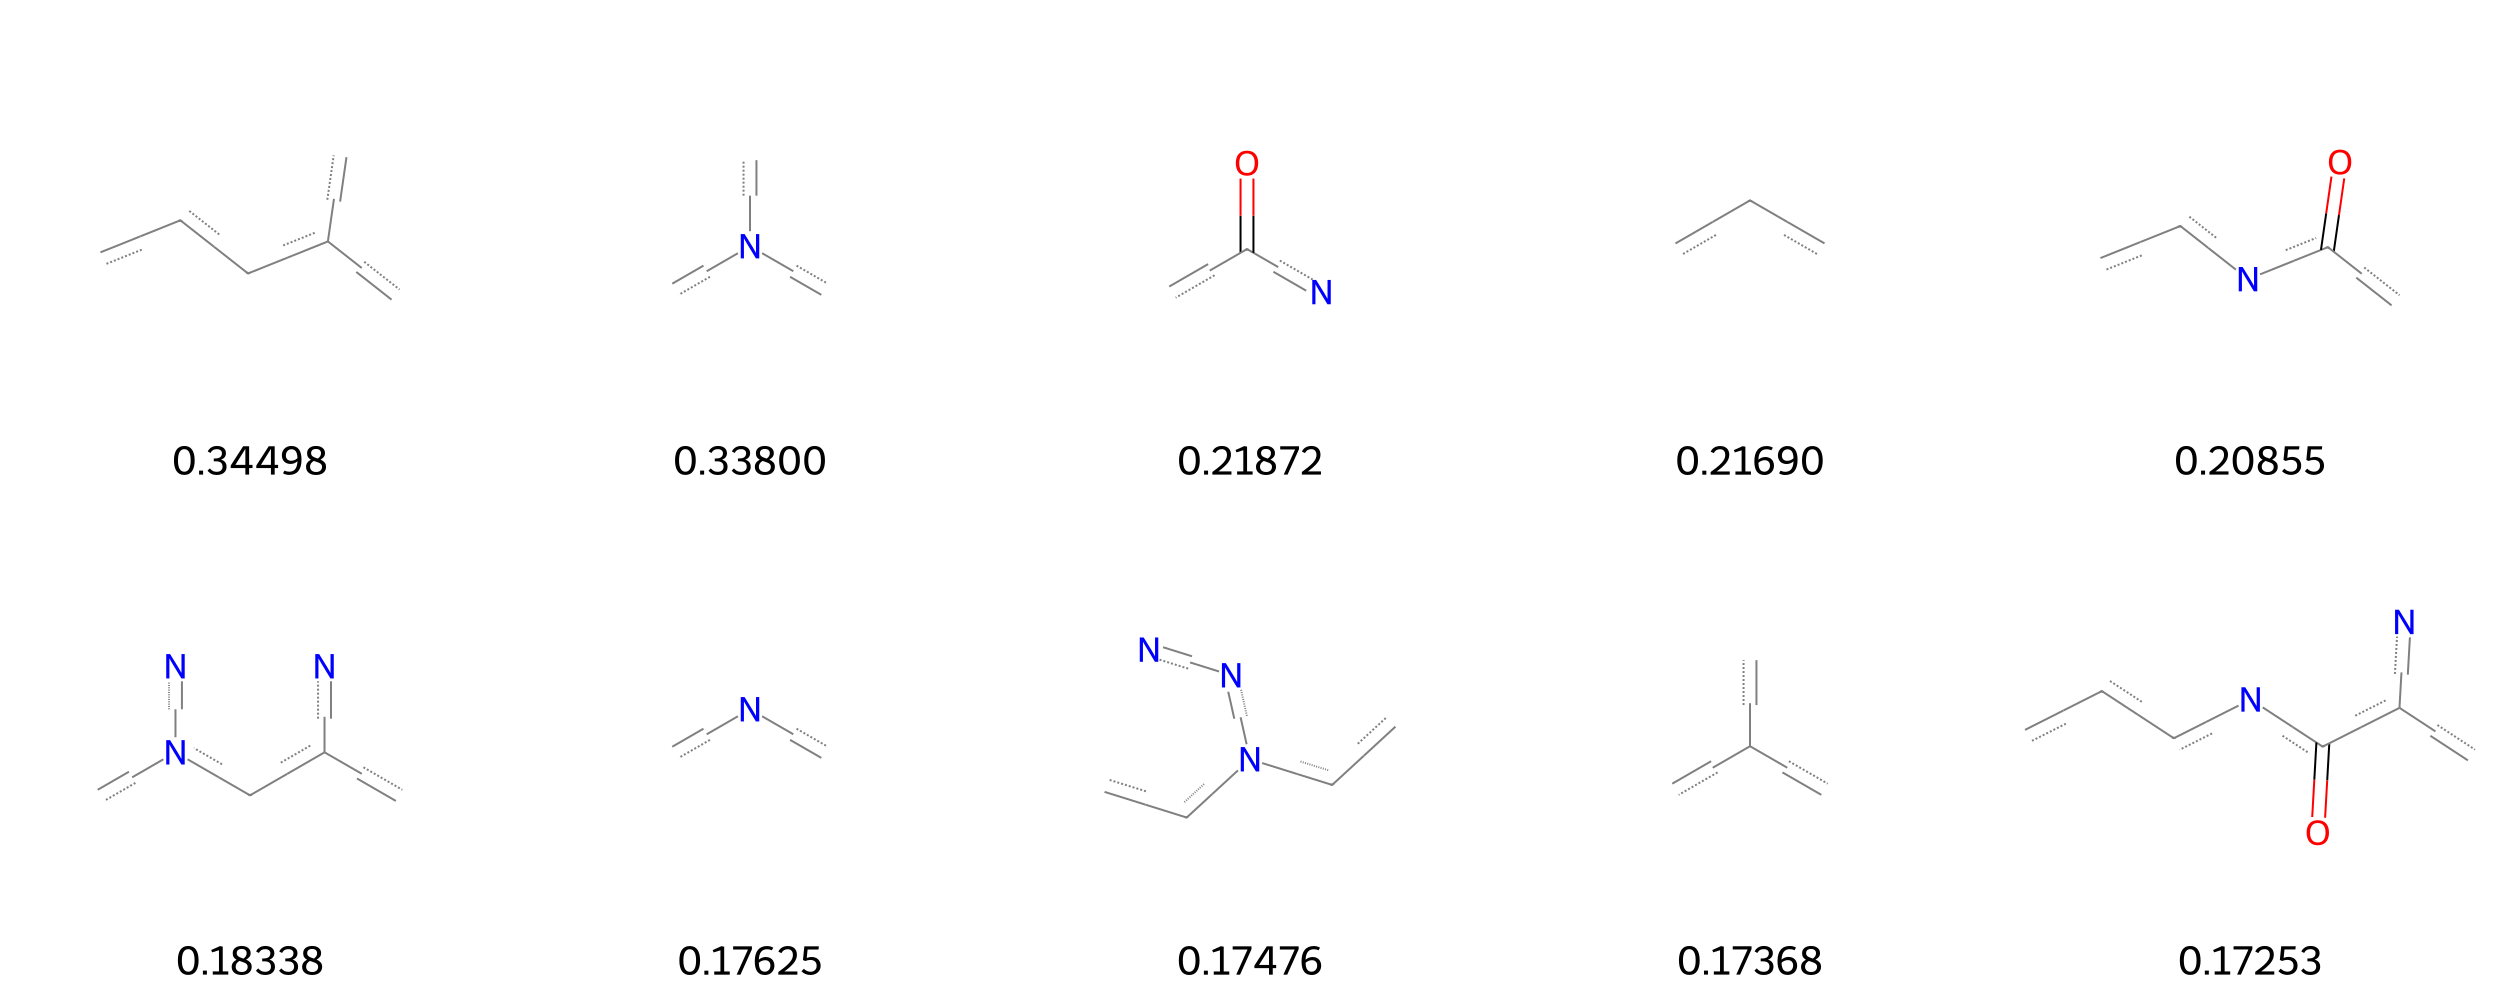

In [10]:
shap = model.predict_from_smiles(test_smiles, explain=True)
shap.head(10)

import rdkit
from rdkit import Chem
from rdkit.Chem import Draw

mols = [Chem.MolFromSmarts(smiles) for smiles in shap['info'][:10]]
shap_vals = shap['shap_value'][:10].tolist()
shap_vals_5dp=[]
for x in shap_vals:
    num = '{:.5f}'.format(x)
    shap_vals_5dp.append(num)
shap_val_str = list(map(str, shap_vals_5dp))

options = Draw.MolDrawOptions()
options.legendFontSize = 40

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(500,500), legends=(shap_val_str), useSVG=False, drawOptions=options)
# mol_img.save(fp=r'M:\ML_scripts\MODEL DATA\SHAP_mols.png')

# display(Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200,200), legends=(shap_val_str), useSVG=True))

In [6]:
shap.head(10)

,shap_value,descriptor,bit,info
1573,0.344977,ECFP,1573,c(cc)c(c)c
2009,0.338004,ECFP,2009,N(C)(C)C
1504,0.218716,ECFP,1504,C(N)(=O)c
1325,0.216905,ECFP,1325,C(C)C
1351,0.208548,ECFP,1351,N(CC)C(=O)C
25,0.183380,ECFP,25,c(n(C)n)c(n)C
1866,0.176253,ECFP,1866,N(C)C
86,0.174759,ECFP,86,n(CC)(cc)nn
1754,0.173679,ECFP,1754,c(C)(c)c
626,0.172531,ECFP,626,N(CCC)C(=O)C(C)N


# Hardcoded RFC

QSARtunaModel(predictor=RandomForestClassifier(class_weight='balanced', max_depth=5, max_features=1.0,
                       n_estimators=137, n_jobs=-1, random_state=42), descriptor=MACCS_keys(name='MACCS_keys', parameters=MACCS_keys.Parameters()), mode=<ModelMode.CLASSIFICATION: 'classification'>, transform=None, aux_transform=None, metadata={'name': '', 'buildconfig': {'data': {'training_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\sample_then_split\\train_set.csv', 'input_column': 'Structure', 'response_column': 'Class', 'response_type': 'classification', 'deduplication_strategy': {'name': 'KeepMedian'}, 'split_strategy': {'name': 'NoSplitting'}, 'test_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\sample_then_split\\test_set.csv', 'save_intermediate_files': False, 'log_transform': False, 'log_transform_base': None, 'log_transform_negative': None, 'log_transform_unit_conversion': None, 'probabilistic_threshold_representation': False, 'probabilistic_threshold_representation_threshold':

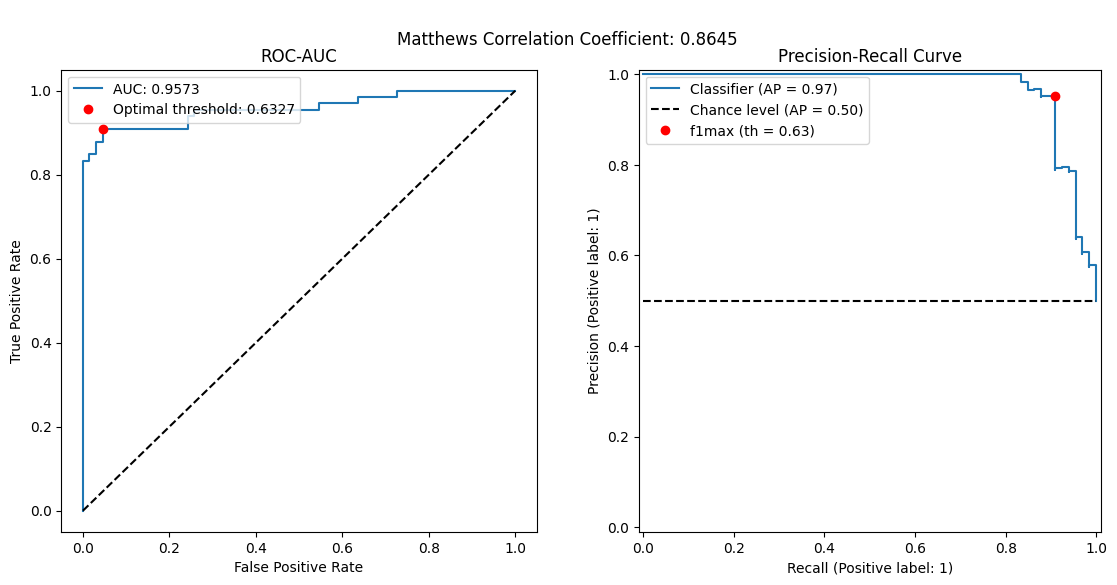

In [22]:
config2 = OptimizationConfig(
    data=Dataset(
            input_column='Structure',
            response_column='Class',
            training_dataset_file=r'M:\ML_scripts\MODEL DATA\sample_then_split\train_set.csv',
            test_dataset_file=r'M:\ML_scripts\MODEL DATA\sample_then_split\test_set.csv',
        ),
        descriptors=[
            ECFP.new(),
            ECFP_counts.new(),
            MACCS_keys.new(),
            PhyschemDescriptors.new(),
            UnscaledPhyschemDescriptors.new(),
            CompositeDescriptor.new(
                descriptors=[
                    ECFP_counts.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            ),
            CompositeDescriptor.new(
                descriptors=[
                    MACCS_keys.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            ),
            CompositeDescriptor.new(
                descriptors=[
                    ECFP.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            )
        ],
        algorithms=[
            RandomForestClassifier.new(),
            # SVC.new(),
            # LogisticRegression.new(),
            # KNeighborsClassifier.new(),
        ],
        settings=OptimizationConfig.Settings(
            mode=ModelMode.CLASSIFICATION,
            cross_validation=10,
            cv_split_strategy=Stratified(),
            n_trials=200,
            n_startup_trials=50,
            direction=OptimizationDirection.MAXIMIZATION,
            random_seed=42,
            n_jobs=-1
        ),
    )

# optimize and build model

# study2 = optimize(config2, study_name='sts_2')
# build_best(buildconfig_best(study2), r"M:\ML_scripts\MODEL DATA\sample_then_split\model_1_RFC.pkl")

with open(r"M:\ML_scripts\MODEL DATA\sample_then_split\model_1_RFC.pkl", "rb") as m:
    model_rf = pickle.load(m)

print(model_rf)

# load test data

fig, axs = plt.subplots(1,2, figsize=(13.5, 6))         # create plots for curves

x = np.linspace(0,1)

test_data = pd.read_csv(config2.data.test_dataset_file)  # load the test data
test_smiles = test_data[config2.data.input_column]       # test structures
y_true = test_data[config2.data.response_column]         # test ground truth labels

y_pred = model_rf.predict_from_smiles(test_smiles)         # model predictions on test set structures

plt.subplot(121)

# Plotting the ROC curve

fpr, tpr, thresh = sklearn.metrics.roc_curve(y_true, y_pred) # false positive rate, true positive rate and thresholds
auc = np.trapz(tpr, fpr)                                     # AUC using trapezoidal rule
plt.plot(fpr, tpr)                                           # plot the ROC curve
axs[0].set_title('ROC-AUC')

# Optimal threshold using ROC curve

optimal_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
optimal_threshold = thresh[optimal_idx]

x_coord, y_coord = fpr[optimal_idx], tpr[optimal_idx]

plt.plot(x_coord, y_coord,'ro');

plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.legend([f'AUC: {auc:.4}', f"Optimal threshold: {optimal_threshold:.4}"], loc='upper left', fontsize=10);
plt.plot(x,x, 'k--', lw=1.5)

# Binary conversion of predictions

y_pred_bin = [1 if value >= optimal_threshold else 0 for value in y_pred]

mcc = matthews_corrcoef(y_pred_bin, y_true)
plt.suptitle(f"\nMatthews Correlation Coefficient: {mcc:.4}")   # matthews CC
# print(classification_report(y_true, y_pred_bin))              # classification report
# print(cm(y_true, y_pred_bin))                                 # confusion matrix

# Plotting the Precision-Recall curve

pos_label = 1 
name = "TM-1"

precision, recall, thresholds = precision_recall_curve(y_true, y_pred, pos_label=pos_label)     # precision, recall and thresholds
f1_scores = 2 * recall * precision / (recall + precision)                                       # https://stats.stackexchange.com/questions/596807/how-to-get-the-threshold-from-precisionrecalldisplay
best_th_ix = np.nanargmax(f1_scores)
best_thresh = thresholds[best_th_ix]

average_precision = average_precision_score(y_true, y_pred, pos_label=pos_label)
display = PrecisionRecallDisplay.from_predictions(y_true=y_true, y_pred=y_pred, pos_label=pos_label, plot_chance_level=True, ax=axs[1])

axs[1].plot(name=name)
axs[1].set_title("Precision-Recall Curve")
axs[1].plot(recall[best_th_ix], precision[best_th_ix], "ro", label=f"f1max (th = {best_thresh:.2f})")
axs[1].legend();


# Model predictions on excluded samples (remnants from downsampling)

QSARtunaModel(predictor=LogisticRegression(class_weight='balanced', n_jobs=-1, random_state=42,
                   solver='newton-cg'), descriptor=ECFP(name='ECFP', parameters=ECFP.Parameters(radius=3, nBits=2048, returnRdkit=False)), mode=<ModelMode.CLASSIFICATION: 'classification'>, transform=None, aux_transform=None, metadata={'name': '', 'buildconfig': {'data': {'training_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\sample_then_split\\train_set.csv', 'input_column': 'Structure', 'response_column': 'Class', 'response_type': 'classification', 'deduplication_strategy': {'name': 'KeepMedian'}, 'split_strategy': {'name': 'NoSplitting'}, 'test_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\sample_then_split\\test_set.csv', 'save_intermediate_files': False, 'log_transform': False, 'log_transform_base': None, 'log_transform_negative': None, 'log_transform_unit_conversion': None, 'probabilistic_threshold_representation': False, 'probabilistic_threshold_representation_threshold': None, 'probabil

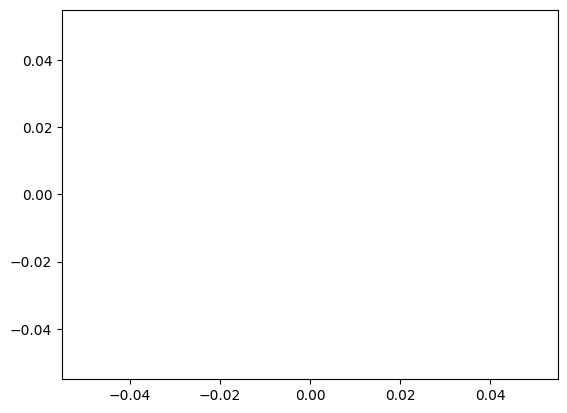

In [19]:
# load models

with open(r"M:\ML_scripts\MODEL DATA\sample_then_split\model_1.pkl", "rb") as m:
    P = pickle.load(m)

print(P)

with open(r"M:\ML_scripts\MODEL DATA\sample_then_split\model_1_RFC.pkl", "rb") as m:
    G = pickle.load(m)

print(G)


# load test data

excl_data = pd.read_csv(r'M:\ML_scripts\MODEL DATA\sample_then_split\excluded_samples.csv')

excl_smiles = excl_data['Structure']
excl_true = excl_data['Class']

# predictions

y_pred_excl = G.predict_from_smiles(excl_smiles)

# ROC curve

fpr_ex, tpr_ex, thresh_ex = sklearn.metrics.roc_curve(excl_true, y_pred_excl)
auc_ex = np.trapz(tpr_ex, fpr_ex)
plt.plot(fpr_ex, tpr_ex)

#  # Optimal threshold using ROC curve
# optimal_idx_ex = np.argmin(np.sqrt(np.square(1-tpr_ex) + np.square(fpr_ex)))
# optimal_threshold_roc_ex = thresh_ex[optimal_idx_ex]

# x_coord_ex, y_coord_ex = fpr_ex[optimal_idx_ex], tpr2[optimal_idx_ex]

# plt.plot(x_coord_ex, y_coord_ex,'ro');
# plt.suptitle('\nROC-AUC')
# plt.legend([f'AUC: {auc_ex:.4}', f"Optimal threshold: {optimal_threshold_roc_ex:.4}"], loc='lower right', fontsize=10);

# binary conversion

# y_pred_bin_excl = [1 if value >= optimal_threshold_roc_ex else 0 for value in y_pred_excl]

# matrix + classif report +  matthewsCC

# print(cm(excl_true, y_pred_bin_excl))
# print('MCC', matthews_corrcoef(y_pred_bin_excl, excl_true))
# print(classification_report(excl_true, y_pred_bin_excl))

# AUPRC

# precision_ex, recall_ex, _ex = precision_recall_curve(excl_true, y_pred_excl)
# display_ex = PrecisionRecallDisplay.from_predictions(excl_true, y_pred_excl, plot_chance_level=True)

# auprc_ex = np.trapz(recall_ex, precision_ex)
# plt.xlabel('Recall')
# plt.ylabel('Precision')

# plt.legend([f'AUC: {auprc2:.4}'], loc='upper right', fontsize=10)

### no positive instances in the test set means recall is set to 1 for all thresholds and no metrics can be generated due to a lack of TPR etc

In [18]:
y_pred_excl

array([0.22928472, 0.22281464, 0.18860478, ..., 0.98258623, 0.47536756,
       0.43245488])